In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
#Dataset Creation
data = {
    'Height_cm': [170, 165, 180, 155, 175, 160, 185, 150, 172, 168,158, 178, 163, 190, 155, 182, 167, 173, 160, 177],
    'Weight_kg': [65, 58, 85, 50, 78, 62, 90, 48, 70, 74,55, 80, 60, 95, 52, 88, 63, 72, 59, 83],
    'Gender':    ['Male', 'Female', 'Male', 'Female', 'Male','Female', 'Male', None, 'Male', 'Female',
                  'Female', 'Male', None, 'Male', 'Female','Male', 'Female', 'Male', None, 'Male']
}
df = pd.DataFrame(data)
print(df)

    Height_cm  Weight_kg  Gender
0         170         65    Male
1         165         58  Female
2         180         85    Male
3         155         50  Female
4         175         78    Male
5         160         62  Female
6         185         90    Male
7         150         48    None
8         172         70    Male
9         168         74  Female
10        158         55  Female
11        178         80    Male
12        163         60    None
13        190         95    Male
14        155         52  Female
15        182         88    Male
16        167         63  Female
17        173         72    Male
18        160         59    None
19        177         83    Male


In [15]:
#Computing BMI
df['Height_m'] = df['Height_cm'] / 100          # convert cm → m
df['BMI']      = df['Weight_kg'] / (df['Height_m'] ** 2)
df['BMI']      = df['BMI'].round(2)              # round to 2 decimal places
df.drop(columns=['Height_m'], inplace=True)      # remove helper column
print(df[['Height_cm', 'Weight_kg', 'Gender', 'BMI']])

    Height_cm  Weight_kg  Gender    BMI
0         170         65    Male  22.49
1         165         58  Female  21.30
2         180         85    Male  26.23
3         155         50  Female  20.81
4         175         78    Male  25.47
5         160         62  Female  24.22
6         185         90    Male  26.30
7         150         48    None  21.33
8         172         70    Male  23.66
9         168         74  Female  26.22
10        158         55  Female  22.03
11        178         80    Male  25.25
12        163         60    None  22.58
13        190         95    Male  26.32
14        155         52  Female  21.64
15        182         88    Male  26.57
16        167         63  Female  22.59
17        173         72    Male  24.06
18        160         59    None  23.05
19        177         83    Male  26.49


In [16]:
#Saving the dataset into CSV file
df.to_csv('bmi_data.csv', index=False)
print("\Dataset saved successfully!")

\Dataset saved successfully!


In [17]:
#Importing The saved CSV file
df = pd.read_csv('bmi_data.csv')
print(df.head(10))
#Null values in Gender Col.
null_count = df['Gender'].isnull().sum()
print(f"Null values in Gender column :{null_count}")

   Height_cm  Weight_kg  Gender    BMI
0        170         65    Male  22.49
1        165         58  Female  21.30
2        180         85    Male  26.23
3        155         50  Female  20.81
4        175         78    Male  25.47
5        160         62  Female  24.22
6        185         90    Male  26.30
7        150         48     NaN  21.33
8        172         70    Male  23.66
9        168         74  Female  26.22
Null values in Gender column :3


In [18]:
#Removing Null values from Gender col.
df = df.dropna(subset=['Gender'])
print(df)

    Height_cm  Weight_kg  Gender    BMI
0         170         65    Male  22.49
1         165         58  Female  21.30
2         180         85    Male  26.23
3         155         50  Female  20.81
4         175         78    Male  25.47
5         160         62  Female  24.22
6         185         90    Male  26.30
8         172         70    Male  23.66
9         168         74  Female  26.22
10        158         55  Female  22.03
11        178         80    Male  25.25
13        190         95    Male  26.32
14        155         52  Female  21.64
15        182         88    Male  26.57
16        167         63  Female  22.59
17        173         72    Male  24.06
19        177         83    Male  26.49


In [20]:
#Structural info.
df.info()
#Statistical info.
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Height_cm  17 non-null     int64  
 1   Weight_kg  17 non-null     int64  
 2   Gender     17 non-null     object 
 3   BMI        17 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 680.0+ bytes
        Height_cm  Weight_kg        BMI
count   17.000000  17.000000  17.000000
mean   171.176471  71.764706  24.214706
std     10.393720  13.930764   2.056557
min    155.000000  50.000000  20.810000
25%    165.000000  62.000000  22.490000
50%    172.000000  72.000000  24.220000
75%    178.000000  83.000000  26.230000
max    190.000000  95.000000  26.570000


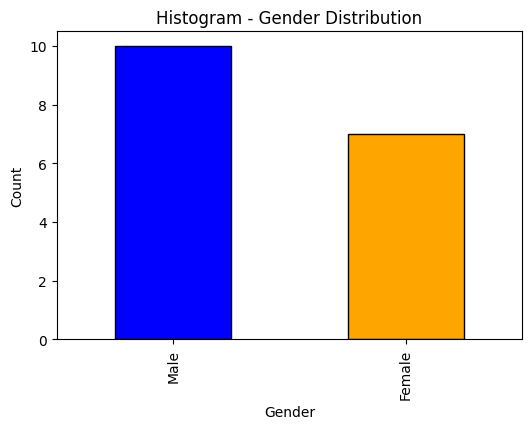

In [24]:
#Histogram on gender col.
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar', color=['blue', 'orange'], edgecolor='black')
plt.title('Histogram - Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

 Inference from Scatter Plot:
   1. Taller people generally weigh more (positive correlation).
   2. Males tend to have higher height and weight than females.
   3. There are no major outliers in this dataset.


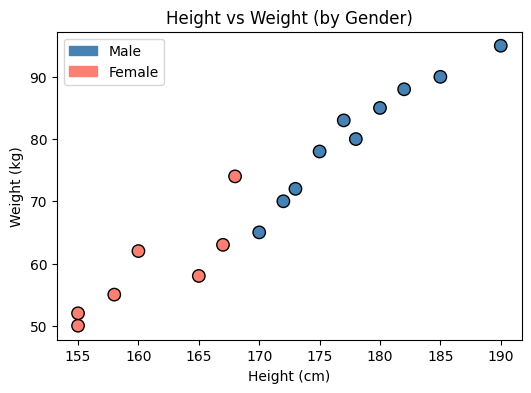

In [27]:
colors = df['Gender'].map({'Male': 'steelblue', 'Female': 'salmon'})
plt.figure(figsize=(6, 4))
plt.scatter(df['Height_cm'], df['Weight_kg'], c=colors, edgecolors='black', s=80)
import matplotlib.patches as mpatches
male_patch   = mpatches.Patch(color='steelblue', label='Male')
female_patch = mpatches.Patch(color='salmon',    label='Female')
plt.legend(handles=[male_patch, female_patch])
 
plt.title('Height vs Weight (by Gender)')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

print(""" Inference from Scatter Plot:
   1. Taller people generally weigh more (positive correlation).
   2. Males tend to have higher height and weight than females.
   3. There are no major outliers in this dataset.""")

In [28]:
#Aggregate functions on height, weight and BMI
for col in ['Height_cm', 'Weight_kg', 'BMI']:
    print(f"\n  Column : {col}")
    print(f"    Mean   : {df[col].mean():.2f}")
    print(f"    Median : {df[col].median():.2f}")
    print(f"    Min    : {df[col].min():.2f}")
    print(f"    Max    : {df[col].max():.2f}")
    print(f"    Sum    : {df[col].sum():.2f}")
    print(f"    Std Dev: {df[col].std():.2f}")


  Column : Height_cm
    Mean   : 171.18
    Median : 172.00
    Min    : 155.00
    Max    : 190.00
    Sum    : 2910.00
    Std Dev: 10.39

  Column : Weight_kg
    Mean   : 71.76
    Median : 72.00
    Min    : 50.00
    Max    : 95.00
    Sum    : 1220.00
    Std Dev: 13.93

  Column : BMI
    Mean   : 24.21
    Median : 24.22
    Min    : 20.81
    Max    : 26.57
    Sum    : 411.65
    Std Dev: 2.06


In [29]:
#Entries where BMI is less than 20
bmi_below_20 = df[df['BMI'] < 20]
if bmi_below_20.empty:
    print("   No entries found with BMI < 20")
else:
    print(bmi_below_20)

   No entries found with BMI < 20
